# Linear Regression with Scikit-learn
**Problem:** Predict student marks from hours studied.

## 1. Import Libraries

We will use:
- **NumPy** for numerical data
- **Matplotlib** for visualization
- **Scikit-learn** for Linear Regression and evaluation metrics


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


## 2. Create a Simple Dataset

We want to predict **marks** from **hours studied**.

In [9]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([20, 30, 40, 50, 60])

print("X:")
print(X)

print("\ny:")
print(y)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


X:
[[1]
 [2]
 [3]
 [4]
 [5]]

y:
[20 30 40 50 60]

Shape of X: (5, 1)
Shape of y: (5,)


## 3. Visualize the Data

Before training, let's see whether a linear relationship appears reasonable.


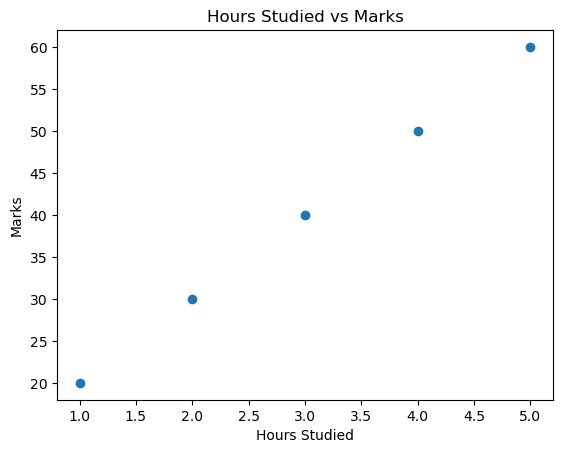

In [10]:
plt.scatter(X, y)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks")

plt.show()


## 4. Create the Linear Regression Model

In [11]:
model = LinearRegression()

print(model)


LinearRegression()


## 5. Train the Model

In [12]:
model.fit(X, y)

print("Model trained successfully.")


Model trained successfully.


## 6. Inspect the Learned Weight and Bias

In [13]:
print("Weight (w):", model.coef_)
print("Bias (b):", model.intercept_)


Weight (w): [10.]
Bias (b): 9.999999999999993


## 7. Predict the Training Data

In [ ]:
y_pred = model.predict(X)

print("Actual values:    ", y)
print("Predicted values: ", y_pred)


Actual values:     [20 30 40 50 60]
Predicted values:  [20. 30. 40. 50. 60.]


## 8. Predict a New Student's Marks

Suppose a student studies for **7 hours**.

The input must still have the shape `(number of samples, number of features)`, so we use `[[7]]`.


In [14]:
X_new = np.array([[7]])

prediction = model.predict(X_new)

print("Predicted marks for 7 hours:", prediction[0])


Predicted marks for 7 hours: 80.0


## 9. Evaluate the Model — Mean Squared Error

In [ ]:
mse = mean_squared_error(y, y_pred)

print("MSE:", mse)


MSE: 1.262177448353619e-29


## 10. Evaluate Using R² Score

Interpretation:
- \(R^2=1\): perfect fit
- \(R^2=0\): model is no better than predicting the mean
- \(R^2<0\): can occur on test data when the model performs worse than the mean baseline


In [ ]:
r2 = r2_score(y, y_pred)

print("R²:", r2)


R²: 1.0


## 11. Plot the Regression Line

The scatter plot shows the actual observations.

The line shows the predictions learned by the model.


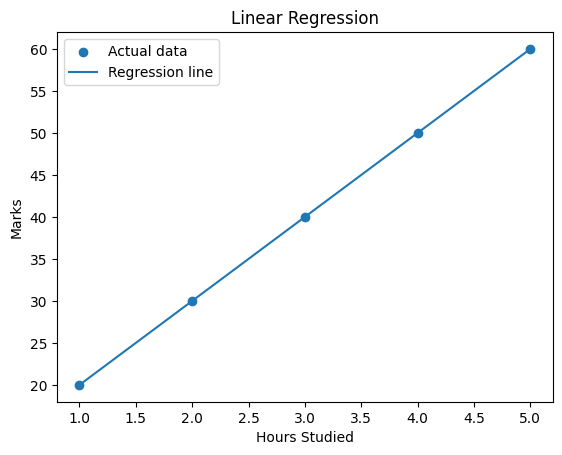

In [ ]:
plt.scatter(X, y, label="Actual data")
plt.plot(X, y_pred, label="Regression line")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Linear Regression")
plt.legend()

plt.show()


# Part B — A More Realistic Dataset

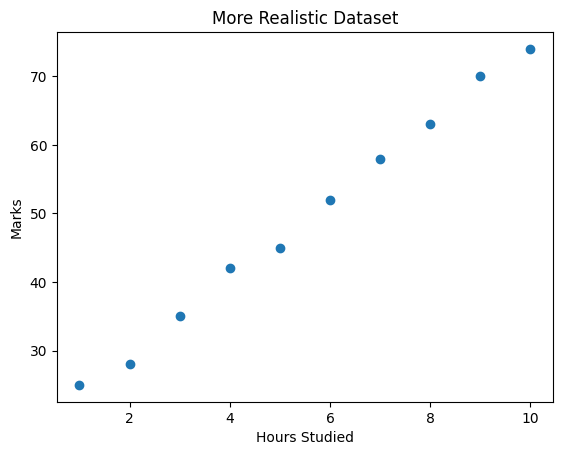

In [ ]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)

y = np.array([25, 28, 35, 42, 45, 52, 58, 63, 70, 74])

plt.scatter(X, y)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("More Realistic Dataset")

plt.show()


## 12. Train a Model on the Realistic Dataset


In [ ]:
model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

print("Weight:", model.coef_[0])
print("Bias:", model.intercept_)
print("MSE:", mean_squared_error(y, y_pred))
print("R²:", r2_score(y, y_pred))


Weight: 5.636363636363637
Bias: 18.200000000000003
MSE: 0.8690909090909088
R²: 0.9966949691622645


## 13. Plot the Best-Fit Line

Notice that the line does not pass through every point. The algorithm finds the line that minimizes the chosen least-squares objective.


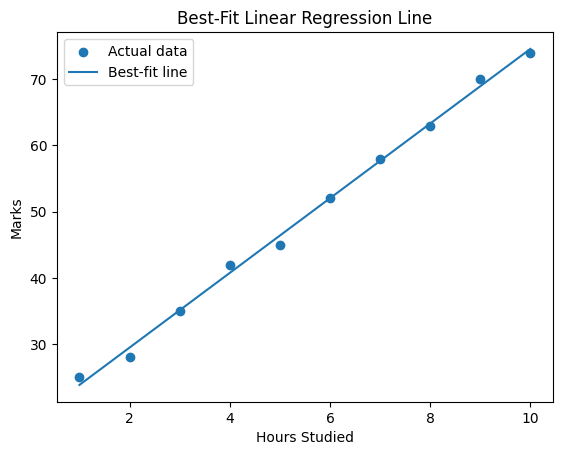

In [ ]:
plt.scatter(X, y, label="Actual data")
plt.plot(X, y_pred, label="Best-fit line")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Best-Fit Linear Regression Line")
plt.legend()

plt.show()


# Part C — Train/Test Split

In a real machine-learning problem, we should not evaluate the model only on the same data used for training.

We split the data into:
- **Training data** → used to learn the model
- **Testing data** → used to evaluate performance on unseen data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.ravel())
print("X_test: ", X_test.ravel())


X_train: [ 6  1  8  3 10  5  4  7]
X_test:  [9 2]


## 14. Train Only on the Training Data


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Weight:", model.coef_[0])
print("Bias:", model.intercept_)


Weight: 5.482758620689656
Bias: 19.094827586206893


## 15. Predict the Test Data


In [ ]:
y_test_pred = model.predict(X_test)

print("Actual test values:    ", y_test)
print("Predicted test values: ", y_test_pred)


Actual test values:     [70 28]
Predicted test values:  [68.43965517 30.06034483]


## 16. Evaluate on Unseen Test Data

This is a more meaningful estimate of how the model performs on data it did not use during training.


In [ ]:
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Test MSE:", test_mse)
print("Test R²:", test_r2)


Test MSE: 3.339848394768131
Test R²: 0.9924266476309113
